# Fisheye camera parameter estimation — SelfSupervisedFisheyeRectification (trained on Places365)

This notebook trains `MasakiHosono/SelfSupervisedFisheyeRectification` on **Places365** images
(as the generic, non-fisheye photos the self-supervised scheme needs), then runs the trained
model on **your 47 real fisheye photos** to estimate a single distortion parameter per image.

**How this method actually works (important):**
- The network never sees real fisheye distortion during training. It takes ordinary photos,
  synthetically fisheye-distorts them with a *known* parameter, and learns to predict that
  parameter back out. Places365 supplies the "ordinary photos" pool.
- Your own fisheye images are only used at the very end, for **inference** (`predict.py`), to
  get the estimated distortion value for your actual camera.
- The output is a single scalar distortion parameter (division model, range `[-1, 1]`) — not a
  full (fx, fy, cx, cy, k1, k2, ...) intrinsics set.

**Before running, in the Kaggle notebook sidebar:**
1. Settings → Accelerator → **GPU T4 x2** (or any GPU).
2. Settings → Internet → **On** (needed to `git clone` the repo and for `torch.hub.load` inside
   the model, which fetches an old torchvision hub definition).
3. Add Data →
   - search **"Places365"** and add a Places365 (or Places365-Standard small/validation subset)
     Kaggle dataset — any of the public Places365 mirrors on Kaggle will do; you don't need all
     ~1.8M images, a subset of ~36,500 is exactly what was discussed.
   - upload your own 47 fisheye photos as a private dataset and add it too.
4. Update the two path variables in the "Locate your data" cell below to match whatever the
   Kaggle UI names your two datasets under `/kaggle/input/...`.


In [6]:
import os

root = '/kaggle/input/datasets/soumikrakshit/nyu-depth-v2/nyu_data/data/nyu2_train'
subfolders = os.listdir(root)
print(f'{len(subfolders)} subfolders')
print(subfolders[:5])

# peek inside one
sample_folder = os.path.join(root, subfolders[0])
print(os.listdir(sample_folder)[:10])

284 subfolders
['living_room_0020_out', 'bedroom_0140_out', 'kitchen_0019b_out', 'living_room_0050_out', 'bedroom_0067a_out']
['208.jpg', '173.png', '248.png', '333.jpg', '45.jpg', '94.png', '56.jpg', '89.jpg', '20.jpg', '275.jpg']


In [ ]:
!git clone https://huggingface.co/datasets/Gen3DF/Matterport3d

Cloning into 'Matterport3d'...
Username for 'https://huggingface.co': 

## 1. Check GPU and clone the repo

In [1]:
!nvidia-smi


Mon Jul 27 23:16:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

REPO_DIR = "/kaggle/working/SelfSupervisedFisheyeRectification"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/MasakiHosono/SelfSupervisedFisheyeRectification.git {REPO_DIR}
else:
    print("repo already cloned")

os.chdir(REPO_DIR)
print("cwd:", os.getcwd())


Cloning into '/kaggle/working/SelfSupervisedFisheyeRectification'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 79 (delta 29), reused 42 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 3.68 MiB | 11.92 MiB/s, done.
Resolving deltas: 100% (29/29), done.
cwd: /kaggle/working/SelfSupervisedFisheyeRectification


## 2. Install dependencies

The repo's `requirements.txt` is empty, so we install everything it actually imports:
`torch`/`torchvision` (already on Kaggle), `torchsummary`, `opencv-python`, `scipy`, `pyyaml`,
`matplotlib`, `pillow`.

In [3]:
!pip install -q torchsummary opencv-python-headless scipy pyyaml matplotlib pillow


## 3. Patch two upstream bugs

Reading the actual source turned up two bugs that will crash a fresh run on any current
environment (including Kaggle):

1. `src/core/config.py` calls `yaml.load(f)` with no `Loader` argument. PyYAML 6.x (what Kaggle
   ships) requires one explicitly and raises `TypeError` otherwise.
2. `src/train.py` calls `plt.plot(...)` / `plt.savefig(...)` every epoch but never imports
   `matplotlib.pyplot`, so training crashes at the end of epoch 1 with `NameError`.

We patch both in place, plus make `torch.load` robust to running with/without a GPU.

In [4]:
config_path = "src/core/config.py"
with open(config_path) as f:
    content = f.read()

if "yaml.load(f)" in content:
    content = content.replace("yaml.load(f)", "yaml.load(f, Loader=yaml.FullLoader)")
    with open(config_path, "w") as f:
        f.write(content)
    print("patched", config_path)
else:
    print("already patched or pattern not found:", config_path)


patched src/core/config.py


In [5]:
train_path = "src/train.py"
with open(train_path) as f:
    content = f.read()

if "import matplotlib.pyplot as plt" not in content:
    content = content.replace(
        "from torchsummary import summary",
        "from torchsummary import summary\nimport matplotlib.pyplot as plt",
    )
    with open(train_path, "w") as f:
        f.write(content)
    print("patched", train_path)
else:
    print("already patched:", train_path)


patched src/train.py


In [6]:
train_path = "src/train.py"
with open(train_path) as f:
    content = f.read()

if "import matplotlib.pyplot as plt" not in content:
    content = content.replace(
        "from torchsummary import summary",
        "from torchsummary import summary\nimport matplotlib.pyplot as plt",
    )
    with open(train_path, "w") as f:
        f.write(content)
    print("patched", train_path)
else:
    print("already patched:", train_path)


already patched: src/train.py


In [7]:
# Make checkpoint loading robust whether or not a GPU is present in this session
for fname in ["src/train.py", "src/predict.py", "src/test.py"]:
    with open(fname) as f:
        content = f.read()
    old = "torch.load(model_state_file)" if "model_state_file" in content else "torch.load(model_file)"
    var = "model_state_file" if "model_state_file" in content else "model_file"
    new = f"torch.load({var}, map_location=DEVICE)"
    if old in content and new not in content:
        content = content.replace(old, new)
        with open(fname, "w") as f:
            f.write(content)
        print("patched checkpoint loading in", fname)


patched checkpoint loading in src/train.py
patched checkpoint loading in src/predict.py
patched checkpoint loading in src/test.py


In [8]:
for fname, old_line in [
    ("src/datasets/distort_dataset.py", "image = Image.open(image_file)"),
    ("src/datasets/eval_dataset.py", "image = Image.open(image_file)"),
]:
    with open(fname) as f:
        content = f.read()
    new_line = "image = Image.open(image_file).convert(\"RGB\")"
    if old_line in content and new_line not in content:
        content = content.replace(old_line, new_line)
        with open(fname, "w") as f:
            f.write(content)
        print("patched", fname)
    else:
        print("already patched or pattern not found:", fname)


patched src/datasets/distort_dataset.py
patched src/datasets/eval_dataset.py


## 4. Locate your data

Edit `PLACES365_DIR` and `FISHEYE_DIR` below to match the folder names Kaggle assigned your two
added datasets under `/kaggle/input/`. Run the `!ls /kaggle/input` cell first if you're not sure
of the exact names.

In [9]:
!ls /kaggle/input


datasets


In [10]:
# >>> EDIT THESE TWO PATHS to match your /kaggle/input folder names <<<
# PLACES365_DIR = "/kaggle/input/datasets/qweasd123456785432/val256/val_256"   # folder containing the ~36,500 Places365 images (any nesting is fine)
PLACES365_DIR = "/kaggle/input/datasets/qweasd123456785432/asd123/asd"
FISHEYE_DIR   = "/kaggle/input/datasets/qweasd123456785432/images/images"   # folder containing your 47 real fisheye photos

assert os.path.exists(PLACES365_DIR), f"Not found: {PLACES365_DIR} -- check the name under /kaggle/input"
assert os.path.exists(FISHEYE_DIR), f"Not found: {FISHEYE_DIR} -- check the name under /kaggle/input"
print("OK, both paths exist")


OK, both paths exist


## 5. Build `train.lst` / `val.lst`

The repo expects `data/<dataset_name>/train.lst` and `val.lst` — plain text files, one absolute
image path per line. There's no bundled script that actually does this (the shipped
`tools/prepare_cityscapes.py` is just a docstring), so we build the lists directly.

In [11]:
import random

DATASET_NAME = "places365"
data_root = os.path.join("data", DATASET_NAME)
os.makedirs(data_root, exist_ok=True)

exts = (".jpg", ".jpeg", ".png")
image_paths = []
for root, _, files in os.walk(PLACES365_DIR):
    for fname in files:
        if fname.lower().endswith(exts):
            image_paths.append(os.path.join(root, fname))

print(f"found {len(image_paths)} images under {PLACES365_DIR}")

random.seed(0)
random.shuffle(image_paths)

val_ratio = 0.1
n_val = max(1, int(len(image_paths) * val_ratio))
val_paths = image_paths[:n_val]
train_paths = image_paths[n_val:]

with open(os.path.join(data_root, "train.lst"), "w") as f:
    f.write("\n".join(train_paths))
with open(os.path.join(data_root, "val.lst"), "w") as f:
    f.write("\n".join(val_paths))

print(f"train: {len(train_paths)}  val: {len(val_paths)}  -> {data_root}")


found 1010 images under /kaggle/input/datasets/qweasd123456785432/asd123/asd
train: 909  val: 101  -> data/places365


## 6. Write the config file

Same schema as the repo's `cfg/cityscapes.yml`. Epoch count is reduced from the default `1000`
to fit a single Kaggle GPU session — with ~36,500 training images per epoch you'll cover far
more data per epoch than the original Cityscapes run (~2,975 images), so fewer epochs are
needed. Training checkpoints every epoch to `outputs/places365/checkpoint.pth.tar` and
auto-resumes from it, so if your session gets cut off, just rerun the training cell (after
re-running the setup cells) to continue where it left off.

In [12]:
import yaml

cfg = {
    "DATASET": {"NAME": DATASET_NAME, "HEIGHT": 256, "WIDTH": 512},
    "TRAIN": {
        "MAX_EPOCH": 100,          # lower than the paper's 1000; raise if you have session time to spare
        "BATCH_SIZE": 16,
        "LEARNING_RATE": 0.0001,
        "CURRICULUM": {"ENABLED": True, "SWITCH_EPOCH": 5},
    },
    "TEST": {
        "CHECKPOINT": "checkpoint.pth.tar",
        "SAVE_RESULTS": True,
        "OUTPUT_SIZE": {"HEIGHT": 720, "WIDTH": 1280},
    },
}

cfg_path = f"cfg/{DATASET_NAME}.yml"
with open(cfg_path, "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print("wrote", cfg_path)
print(open(cfg_path).read())


wrote cfg/places365.yml
DATASET:
  HEIGHT: 256
  NAME: places365
  WIDTH: 512
TEST:
  CHECKPOINT: checkpoint.pth.tar
  OUTPUT_SIZE:
    HEIGHT: 720
    WIDTH: 1280
  SAVE_RESULTS: true
TRAIN:
  BATCH_SIZE: 16
  CURRICULUM:
    ENABLED: true
    SWITCH_EPOCH: 5
  LEARNING_RATE: 0.0001
  MAX_EPOCH: 100



## 7. Train

This calls the repo's own `src/train.py`, unmodified apart from the two bugfixes above. It
prints a model summary, then per-epoch train/val loss. Expect this to take a while for
30 epochs over ~33k images — keep an eye on the Kaggle session time limit.

In [13]:
!python3 src/train.py cfg/{DATASET_NAME}.yml


torch.cuda.is_available(): True
Downloading: "https://github.com/pytorch/vision/zipball/v0.6.0" to /root/.cache/torch/hub/v0.6.0.zip
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 254, 510]           1,792
            Conv2d-2         [-1, 64, 254, 510]           1,792
            Conv2d-3         [-1, 64, 252, 508]          36,928
            Conv2d-4         [-1, 64,

## 8. Run inference on your 47 real fisheye photos

This calls `src/predict.py`, which loads the checkpoint just trained and, for each image in
`FISHEYE_DIR`, prints the estimated distortion parameter and writes a rectified image to
`FISHEYE_DIR/out/` (or a working copy, since `/kaggle/input` is read-only — handled below by
copying your fisheye images into a writable folder first).

In [14]:
import shutil

writable_fisheye_dir = "/kaggle/working/fisheye_input"
os.makedirs(writable_fisheye_dir, exist_ok=True)

for fname in os.listdir(FISHEYE_DIR):
    src = os.path.join(FISHEYE_DIR, fname)
    dst = os.path.join(writable_fisheye_dir, fname)
    if os.path.isfile(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

print(f"copied fisheye images to writable dir: {writable_fisheye_dir}")


copied fisheye images to writable dir: /kaggle/working/fisheye_input


In [16]:
!python3 src/predict.py cfg/{DATASET_NAME}.yml -i {writable_fisheye_dir} -oh 1920 -ow 1080


torch.cuda.is_available(): True
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.6.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
=> load outputs/places365/checkpoint.pth.tar
Got -0.21012447774410248 for ('/kaggle/working/fisheye_input/im_calib_37.jpg',)
FisheyeEffector was initialized with distortion = -0.21012447774410248
Got -0.20302699506282806 for ('/kaggle/working/fisheye_input/im_calib_25.jpg',)
FisheyeEffector was initialized with distortion = -0.20302699506282806
Got -0.2195296436548233 for ('/kaggle/working/

## 9. Collect the per-image estimates and average them

Since all 47 photos come from the same physical camera, the single most useful number is the
mean distortion parameter across all of them.

In [17]:
import subprocess, re, statistics

result = subprocess.run(
    ["python3", "src/predict.py", f"cfg/{DATASET_NAME}.yml", "-i", writable_fisheye_dir,
     "-oh", "1920", "-ow", "1080"],
    capture_output=True, text=True,
)
print(result.stdout[-3000:])  # tail of stdout, in case it's long

values = [float(v) for v in re.findall(r"Got ([-\d.]+) for", result.stdout)]
print(f"\ncollected {len(values)} estimates")
if values:
    print("per-image distortion estimates:", values)
    print("mean distortion parameter:", statistics.mean(values))
    print("std dev:", statistics.pstdev(values) if len(values) > 1 else 0.0)


2869311273097992 for ('/kaggle/working/fisheye_input/im_calib_07.jpg',)
FisheyeEffector was initialized with distortion = -0.22869311273097992
Got -0.2040291279554367 for ('/kaggle/working/fisheye_input/im_calib_18.jpg',)
FisheyeEffector was initialized with distortion = -0.2040291279554367
Got -0.21730151772499084 for ('/kaggle/working/fisheye_input/im_calib_35.jpg',)
FisheyeEffector was initialized with distortion = -0.21730151772499084
Got -0.2038339376449585 for ('/kaggle/working/fisheye_input/im_calib_36.jpg',)
FisheyeEffector was initialized with distortion = -0.2038339376449585
Got -0.2236616313457489 for ('/kaggle/working/fisheye_input/im_calib_34.jpg',)
FisheyeEffector was initialized with distortion = -0.2236616313457489
Got -0.20637378096580505 for ('/kaggle/working/fisheye_input/im_calib_12.jpg',)
FisheyeEffector was initialized with distortion = -0.20637378096580505
Got -0.2331008017063141 for ('/kaggle/working/fisheye_input/im_calib_45.jpg',)
FisheyeEffector was initializ

## 10. Preview a few rectified results

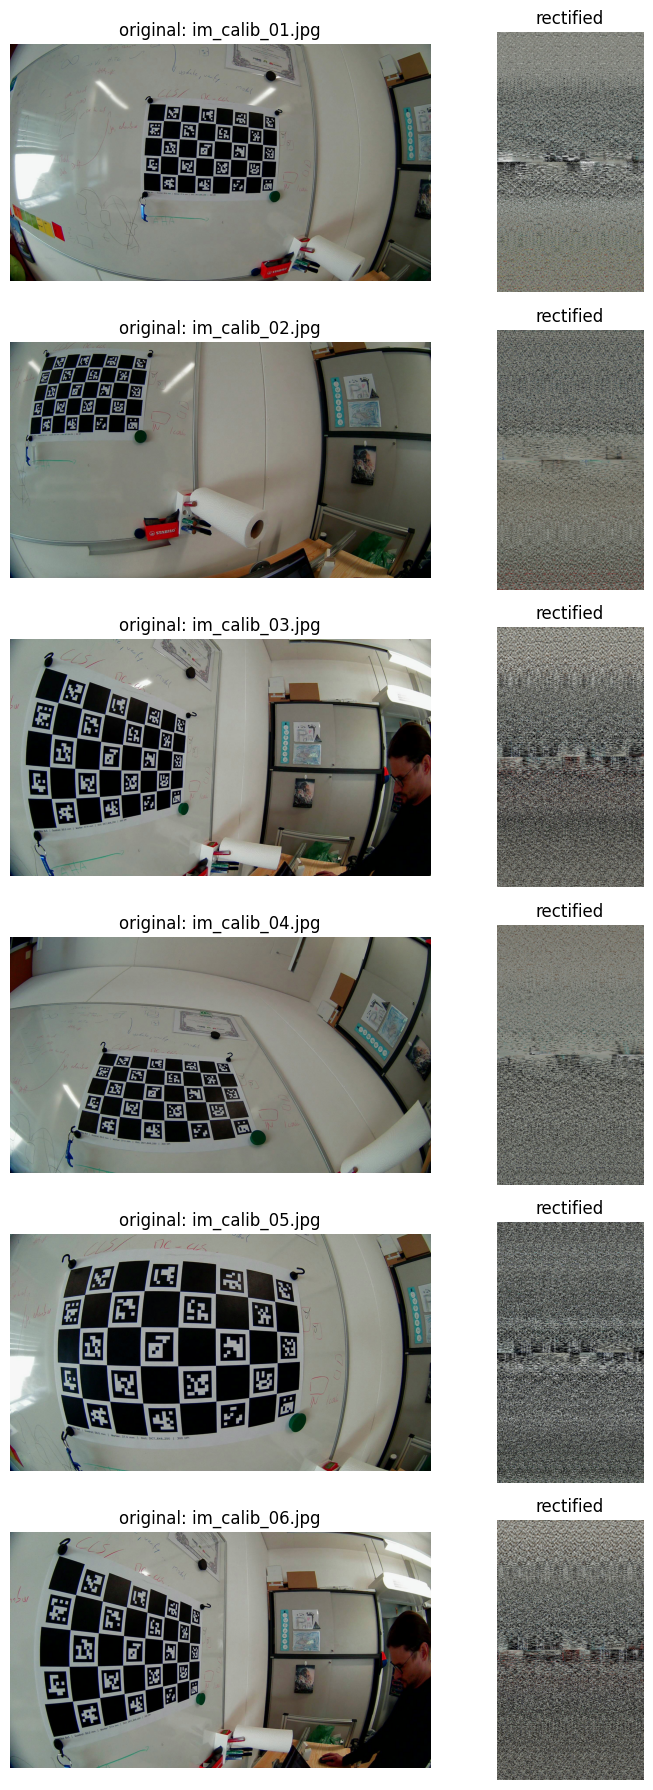

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

out_dir = os.path.join(writable_fisheye_dir, "out")
out_files = sorted(os.listdir(out_dir))[:6]

fig, axes = plt.subplots(len(out_files), 2, figsize=(8, 3 * len(out_files)))
if len(out_files) == 1:
    axes = [axes]

for i, fname in enumerate(out_files):
    orig = Image.open(os.path.join(writable_fisheye_dir, fname))
    rect = Image.open(os.path.join(out_dir, fname))
    axes[i][0].imshow(orig); axes[i][0].set_title(f"original: {fname}"); axes[i][0].axis("off")
    axes[i][1].imshow(rect); axes[i][1].set_title("rectified"); axes[i][1].axis("off")

plt.tight_layout()
plt.show()


---
### Notes

- The estimated value is a single scalar in the division-model distortion range `[-1, 1]`, not
  a full calibration (no focal length or principal point). If you need full intrinsics, this
  model isn't the right tool on its own.
- `outputs/places365/checkpoint.pth.tar` and `cfg/places365.yml` are left in `/kaggle/working`,
  so they're saved automatically as this notebook's Output when you commit it — you can restart
  a later session from the same checkpoint by re-running cells 1–6, then training again (it will
  resume from the saved epoch) before re-running inference.
- If Kaggle's session limit cuts off training, just commit/save the notebook, then reopen a new
  session, redo the setup cells, and rerun the training cell — it auto-resumes.
